# Exploratory Time-Series Visualization for Onset Diagnostics

This notebook provides a reusable function for plotting daily meteorological time-series from raw data to support sanity checks and interpretability of onset detection.

## 1) Design (Reusable Function Contract)

The function `plot_onset_timeseries(...)` is designed to:
- take a single-point daily rainfall time-series and threshold
- show intermediate onset logic (rolling sum, first-day condition, onset condition)
- return `fig, axes, diagnostics` for reuse in debugging and batch workflows.

## 2) Imports

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from monsoonbench.metrics.base import OnsetMetricsBase
from monsoonbench.metrics.probabilistic import ProbabilisticOnsetMetrics
from monsoonbench.metrics.deterministic import DeterministicOnsetMetrics


## 3) Paths and Example Settings

In [9]:
# Robust repo root detection
cwd = Path.cwd()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'pyproject.toml').exists()), cwd)

data_dir = repo_root / 'data'
out_dir = repo_root / 'examples' / 'demo_notebooks' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

imd_1deg_dir = data_dir / 'imd_rainfall_data' / '1p0'
thres_1deg_file = data_dir / 'imd_onset_threshold' / 'mwset1x1.nc4'

# Example point/year (you can change these)
example_year = 2019
example_lat = 24.5
example_lon = 80.5

print('repo_root =', repo_root)
print('example =', example_year, example_lat, example_lon)

# Benchmark-oriented settings (model vs IMD truth)
imd_4deg_dir = data_dir / 'imd_rainfall_data' / '4p0'
thres_4deg_file = data_dir / 'imd_onset_threshold' / 'mwset4x4.nc4'

# Model configs for cross-type comparison
# date_filter_year is only used for probabilistic models
cross_type_model_configs = [
    {
        'model_name': 'aifs',
        'model_type': 'deterministic',
        'model_forecast_dir': data_dir / 'rainfall_4p0' / 'AIFS',
    },
    {
        'model_name': 'graphcast',
        'model_type': 'deterministic',
        'model_forecast_dir': data_dir / 'rainfall_4p0' / 'GraphCast',
    },
    {
        'model_name': 'ifs',
        'model_type': 'probabilistic',
        'model_forecast_dir': data_dir / 'rainfall_4p0' / 'IFS_S2S',
        'mem_num': 11,
        'date_filter_year': 2024,
    },
    {
        'model_name': 'ngcm',
        'model_type': 'probabilistic',
        'model_forecast_dir': data_dir / 'rainfall_4p0' / 'NeuralGCM',
        'mem_num': 51,
        'date_filter_year': 2024,
    },
]

print('cross-type model count =', len(cross_type_model_configs))


repo_root = c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench
example = 2019 24.5 80.5
cross-type model count = 4


## 4) Helper Functions

In [10]:
def standardize_rainfall_dims(rain: xr.DataArray) -> xr.DataArray:
    rename_map = {}
    if 'TIME' in rain.dims:
        rename_map['TIME'] = 'time'
    if 'LATITUDE' in rain.dims:
        rename_map['LATITUDE'] = 'lat'
    if 'LONGITUDE' in rain.dims:
        rename_map['LONGITUDE'] = 'lon'
    if rename_map:
        rain = rain.rename(rename_map)
    return rain.transpose('time', 'lat', 'lon')


def compute_onset_diagnostics(
    rain_ts: xr.DataArray,
    sum_threshold: float,
    year: int,
    window: int = 5,
    first_day_threshold: float = 1.0,
    mok: bool = True,
    mok_month: int = 6,
    mok_day: int = 2,
) -> dict:
    """Compute onset intermediate diagnostics for one point time-series."""
    ts = rain_ts.copy().sortby('time')
    time_index = pd.to_datetime(ts.time.values)

    rolling_sum = ts.rolling(time=window, min_periods=window).sum().shift(time=-(window - 1))
    first_day_condition = ts > first_day_threshold
    sum_condition = rolling_sum > float(sum_threshold)
    onset_condition = first_day_condition & sum_condition

    if mok:
        start_date = pd.Timestamp(year=year, month=mok_month, day=mok_day)
    else:
        start_date = pd.Timestamp(year=year, month=5, day=1)

    # Keep consistent with existing repository logic (> start_date)
    date_mask = xr.DataArray(time_index > start_date, coords={'time': ts.time}, dims=['time'])
    valid_condition = onset_condition & date_mask

    idx = np.where(valid_condition.values)[0]
    onset_date = pd.to_datetime(ts.time.values[idx[0]]) if len(idx) > 0 else pd.NaT
    candidate_dates = pd.to_datetime(ts.time.values[idx])

    return {
        'rain_ts': ts,
        'rolling_sum': rolling_sum,
        'first_day_condition': first_day_condition,
        'sum_condition': sum_condition,
        'onset_condition': onset_condition,
        'valid_condition': valid_condition,
        'date_mask': date_mask,
        'start_date': start_date,
        'onset_date': onset_date,
        'candidate_dates': candidate_dates,
        'sum_threshold': float(sum_threshold),
        'window': window,
        'first_day_threshold': float(first_day_threshold),
    }


def plot_onset_timeseries(
    rain_ts: xr.DataArray,
    sum_threshold: float,
    year: int,
    window: int = 5,
    first_day_threshold: float = 1.0,
    mok: bool = True,
    mok_month: int = 6,
    mok_day: int = 2,
    title_prefix: str | None = None,
    save_path: Path | None = None,
    simple_mode: bool = True,
    show_condition_panel: bool = False,
):
    """Readable sanity-check plot for single-point onset diagnostics.

    Default behavior is compact and presentation-friendly:
    - 2 panels (rainfall, rolling sum)
    - Minimal legend
    - Key dates highlighted

    Optional:
    - show_condition_panel=True adds a third panel for boolean conditions.
    """
    diagnostics = compute_onset_diagnostics(
        rain_ts=rain_ts,
        sum_threshold=sum_threshold,
        year=year,
        window=window,
        first_day_threshold=first_day_threshold,
        mok=mok,
        mok_month=mok_month,
        mok_day=mok_day,
    )

    ts = diagnostics['rain_ts']
    rolling = diagnostics['rolling_sum']
    start_date = diagnostics['start_date']
    onset_date = diagnostics['onset_date']
    valid_mask = diagnostics['valid_condition'].values.astype(bool)

    # Layout
    if show_condition_panel:
        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12.8, 8.3),
            sharex=True,
            constrained_layout=True,
            gridspec_kw={'height_ratios': [1.2, 1.25, 0.9]},
        )
    else:
        fig, axes = plt.subplots(2, 1, figsize=(12.8, 6.6), sharex=True, constrained_layout=True)

    axes = np.asarray(axes)

    # ---------- Panel 1: Daily rainfall ----------
    ax0 = axes[0]
    ax0.bar(ts.time.values, ts.values, width=0.9, color='#4C78A8', alpha=0.9, edgecolor='none')
    ax0.axhline(first_day_threshold, color='#333333', linestyle='--', linewidth=1.1)
    ax0.set_ylabel('Rainfall (mm/day)')
    ax0.set_title('Daily Rainfall')

    # ---------- Panel 2: Rolling sum ----------
    ax1 = axes[1]
    ax1.plot(rolling.time.values, rolling.values, color='#F58518', linewidth=2.0)
    ax1.axhline(sum_threshold, color='#D62728', linestyle='--', linewidth=1.2)

    if valid_mask.any():
        cand_t = pd.to_datetime(rolling.time.values[valid_mask])
        cand_v = rolling.values[valid_mask]
        ax1.scatter(cand_t, cand_v, color='#2CA02C', s=28, zorder=5)

    # Keep only detected onset window highlighted (avoid clutter)
    if pd.notna(onset_date):
        ax1.axvspan(
            onset_date,
            onset_date + pd.Timedelta(days=window - 1),
            color='#1B9E77',
            alpha=0.14,
            linewidth=0,
        )

    ax1.set_ylabel('Rolling sum (mm)')
    ax1.set_title(f'{window}-Day Rolling Sum and Onset Trigger')

    # ---------- Optional Panel 3: Conditions ----------
    if show_condition_panel:
        ax2 = axes[2]
        t = pd.to_datetime(ts.time.values)
        c_first = diagnostics['first_day_condition'].values.astype(int)
        c_sum = diagnostics['sum_condition'].values.astype(int)
        c_valid = diagnostics['valid_condition'].values.astype(int)

        ax2.step(t, c_first + 0.00, where='mid', linewidth=1.2, color='#1f77b4', label='first_day')
        ax2.step(t, c_sum + 0.08, where='mid', linewidth=1.2, color='#ff7f0e', label='sum_condition')
        ax2.step(t, c_valid + 0.16, where='mid', linewidth=1.3, color='#2ca02c', label='valid_after_MOK')
        ax2.set_ylim(-0.05, 1.35)
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(['False', 'True'])
        ax2.set_ylabel('Conditions')
        ax2.legend(loc='upper left', fontsize=8, frameon=False, ncol=3)

    # ---------- Shared markers ----------
    for ax in axes:
        ax.axvline(start_date, color='gray', linestyle=':', linewidth=1.1)
        if pd.notna(onset_date):
            ax.axvline(onset_date, color='#1B9E77', linestyle='-', linewidth=1.8)
        ax.grid(True, alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Concise legend text (single box)
    legend_lines = [
        f'MOK start: {start_date.date()}',
        f'Detected onset: {onset_date.date() if pd.notna(onset_date) else "NaT"}',
        f'First-day threshold: {first_day_threshold} mm',
        f'{window}-day threshold: {sum_threshold:.2f} mm',
        f'Valid candidates: {int(valid_mask.sum())}',
    ]
    ax1.text(
        0.995,
        0.98,
        '\n'.join(legend_lines),
        transform=ax1.transAxes,
        ha='right',
        va='top',
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.7', alpha=0.95),
    )

    axes[-1].set_xlabel('Date')
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center')

    point_text = ''
    if 'lat' in rain_ts.coords and 'lon' in rain_ts.coords:
        point_text = f" | lat={float(rain_ts.lat.values):.3f}, lon={float(rain_ts.lon.values):.3f}"

    prefix = f"{title_prefix} | " if title_prefix else ''
    fig.suptitle(f"{prefix}{year}{point_text}", fontsize=11)

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=220, bbox_inches='tight', facecolor='white')

    return fig, axes, diagnostics


## 5) Load Raw Data for One Example Point

In [11]:
# Load one-year 1-degree IMD rainfall and threshold
rain_ds = xr.open_dataset(imd_1deg_dir / f'data_{example_year}.nc')
rain_da = standardize_rainfall_dims(rain_ds['RAINFALL'])

thres_1deg = xr.open_dataset(thres_1deg_file)['MWmean'].transpose('lat', 'lon')

# Select nearest gridpoint to requested lat/lon
rain_point = rain_da.sel(lat=example_lat, lon=example_lon, method='nearest')
threshold_point = float(thres_1deg.sel(lat=example_lat, lon=example_lon, method='nearest'))

print('Nearest point used:', float(rain_point.lat.values), float(rain_point.lon.values))
print('Threshold used (mm/5day):', threshold_point)

Nearest point used: 24.5 80.5
Threshold used (mm/5day): 42.4121987448049


## 6) Example Plot (Sanity Check)

Detected onset: 2019-07-02 00:00:00
Number of valid candidates: 33
Saved example plot: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\onset_timeseries_example_2019_24.5_80.5.png


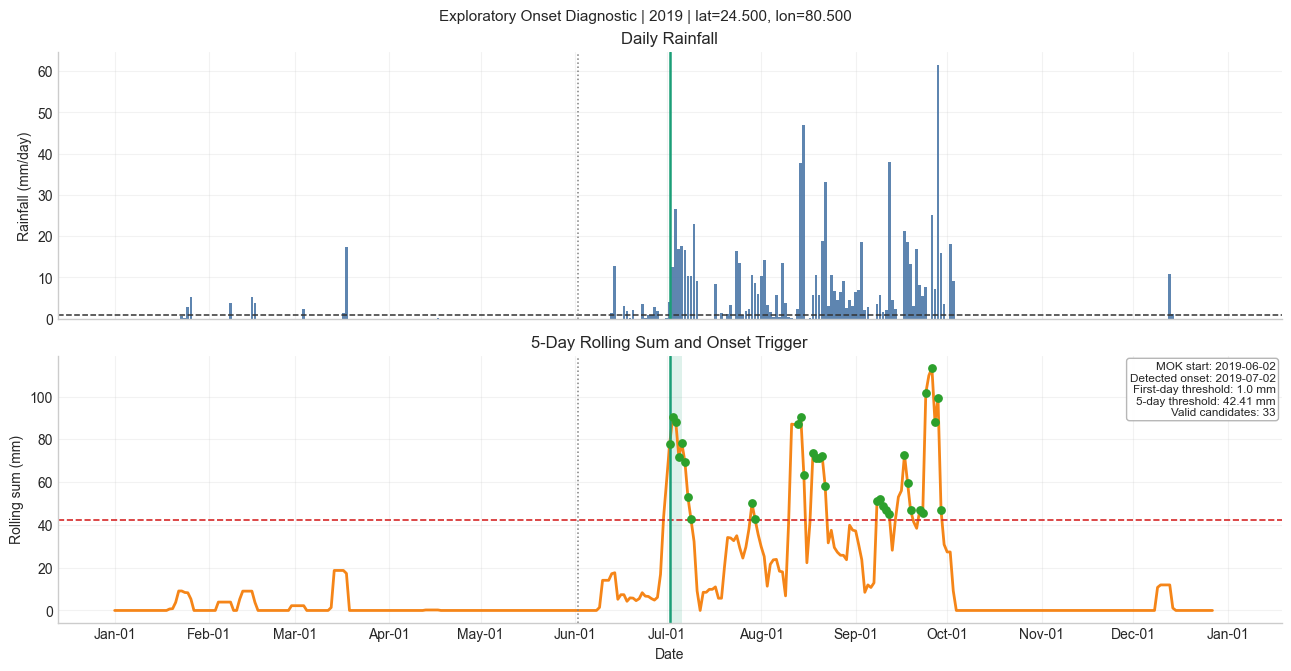

In [12]:
example_plot_path = out_dir / f'onset_timeseries_example_{example_year}_{float(rain_point.lat.values):.1f}_{float(rain_point.lon.values):.1f}.png'

fig, axes, diagnostics = plot_onset_timeseries(
    rain_ts=rain_point,
    sum_threshold=threshold_point,
    year=example_year,
    window=5,
    first_day_threshold=1.0,
    mok=True,
    mok_month=6,
    mok_day=2,
    title_prefix='Exploratory Onset Diagnostic',
    show_condition_panel=False,
    save_path=example_plot_path,
)

print('Detected onset:', diagnostics['onset_date'])
print('Number of valid candidates:', len(diagnostics['candidate_dates']))
print('Saved example plot:', example_plot_path)
plt.show()

## 7) Reuse Tips

- Run multiple points: call `plot_onset_timeseries(...)` inside a loop.
- Run different resolutions: pass matching `rain_ts` and `sum_threshold`.
- Numeric debug only: call `compute_onset_diagnostics(...)` directly.

## 8) Cross-Type Benchmark Extension (Deterministic vs Probabilistic + Ensemble Spread)


In [13]:
def load_threshold_with_fix(path: Path) -> xr.DataArray:
    """Load MWmean threshold and fix potential swapped lat/lon coordinates."""
    th = xr.open_dataset(path)['MWmean'].load()
    if set(th.dims) == {'lat', 'lon'}:
        th = th.transpose('lat', 'lon')

    lat_vals = th['lat'].values
    lon_vals = th['lon'].values
    if np.nanmax(lat_vals) > 60 and np.nanmax(lon_vals) < 50:
        th = th.rename({'lat': 'tmp', 'lon': 'lat'}).rename({'tmp': 'lon'}).transpose('lat', 'lon')
    return th


def _nearest_index(vals: np.ndarray, target: float) -> int:
    vals = np.asarray(vals, dtype=float)
    return int(np.nanargmin(np.abs(vals - float(target))))


def _nearest_latlon_index(lat_vals: np.ndarray, lon_vals: np.ndarray, point_lat: float, point_lon: float) -> tuple[int, int]:
    i = _nearest_index(lat_vals, point_lat)
    j = _nearest_index(lon_vals, point_lon)
    return i, j

def _detect_onset_day_from_series(
    forecast_series: np.ndarray,
    threshold_mm_5day: float,
    init_date: pd.Timestamp,
    max_forecast_day: int = 30,
    onset_window: int = 5,
    mok: bool = True,
    mok_month: int = 6,
    mok_day: int = 2,
):
    """Return first onset day (1-based lead day), or None if no onset found."""
    if forecast_series is None:
        return None

    arr = np.asarray(forecast_series, dtype=float)
    need_steps = max_forecast_day + onset_window - 1
    if arr.size < need_steps:
        return None

    mok_date = pd.Timestamp(year=init_date.year, month=mok_month, day=mok_day)

    for day in range(1, max_forecast_day + 1):
        i0 = day - 1
        i1 = i0 + onset_window
        w = arr[i0:i1]
        if np.isnan(w).any():
            continue
        # onset rule used across repo
        if (w[0] > 1.0) and (np.nansum(w) > float(threshold_mm_5day)):
            pred_date = init_date + pd.Timedelta(days=day)
            if mok and pred_date < mok_date:
                continue
            return day
    return None


def _compute_truth_onset_for_point(
    year: int,
    point_lat: float,
    point_lon: float,
    imd_4deg_dir: Path,
    thres_4deg_file: Path,
    mok: bool = True,
):
    thres_4deg = load_threshold_with_fix(thres_4deg_file)
    rain_4deg = OnsetMetricsBase.load_imd_rainfall(year, str(imd_4deg_dir))
    rain_4deg = standardize_rainfall_dims(rain_4deg)

    i_r, j_r = _nearest_latlon_index(rain_4deg.lat.values, rain_4deg.lon.values, point_lat, point_lon)
    nearest_lat = float(rain_4deg.lat.values[i_r])
    nearest_lon = float(rain_4deg.lon.values[j_r])

    i_t, j_t = _nearest_latlon_index(thres_4deg.lat.values, thres_4deg.lon.values, nearest_lat, nearest_lon)
    thres_point = float(thres_4deg.isel(lat=i_t, lon=j_t).values)

    onset_obs = OnsetMetricsBase.detect_observed_onset(rain_4deg, thres_4deg, year, mok=mok)
    truth_onset = pd.to_datetime(onset_obs.isel(lat=i_r, lon=j_r).values)

    return truth_onset, nearest_lat, nearest_lon, thres_point


def _extract_probabilistic_point_timeseries(
    year: int,
    model_name: str,
    model_forecast_dir: Path,
    mem_num: int,
    date_filter_year: int,
    point_lat: float,
    point_lon: float,
    truth_onset: pd.Timestamp,
    threshold_mm_5day: float,
    mok: bool = True,
    max_forecast_day: int = 30,
    onset_window: int = 5,
    min_member_fraction: float = 0.5,
):
    pr = ProbabilisticOnsetMetrics()
    p_model, _ = pr.get_forecast_probabilistic_twice_weekly_2(
        yr=year,
        model_forecast_dir=str(model_forecast_dir),
        mem_num=int(mem_num),
        date_filter_year=int(date_filter_year),
        file_pattern='{}.nc',
    )

    i_p, j_p = _nearest_latlon_index(p_model.lat.values, p_model.lon.values, point_lat, point_lon)
    p_point = p_model.isel(lat=i_p, lon=j_p).transpose('init_time', 'step', 'member')

    rows = []
    member_rows = []

    init_times = pd.to_datetime(p_point.init_time.values)
    members = p_point.member.values

    for t_idx, init_time in enumerate(init_times):
        init_date = pd.to_datetime(init_time)
        if pd.isna(truth_onset) or init_date >= truth_onset:
            continue

        onset_days = []
        for m_idx, m in enumerate(members):
            series = p_point.isel(init_time=t_idx, member=m_idx).values
            od = _detect_onset_day_from_series(
                series,
                threshold_mm_5day,
                init_date,
                max_forecast_day=max_forecast_day,
                onset_window=onset_window,
                mok=mok,
            )
            onset_days.append(od)
            member_rows.append({
                'model_name': model_name,
                'model_type': 'probabilistic_member',
                'year': year,
                'init_time': init_date,
                'member': int(m),
                'onset_day': od,
                'pred_onset_date': (init_date + pd.Timedelta(days=int(od))) if od is not None else pd.NaT,
                'truth_onset_date': truth_onset,
            })

        valid = [d for d in onset_days if d is not None]
        total_members = len(onset_days)
        n_onset = len(valid)
        frac = n_onset / total_members if total_members > 0 else np.nan

        ens_day = None
        if total_members > 0 and frac >= min_member_fraction and n_onset > 0:
            ens_day = int(np.ceil(np.mean(valid)))

        p10 = float(np.percentile(valid, 10)) if n_onset > 0 else np.nan
        p50 = float(np.percentile(valid, 50)) if n_onset > 0 else np.nan
        p90 = float(np.percentile(valid, 90)) if n_onset > 0 else np.nan

        pred_date = (init_date + pd.Timedelta(days=int(ens_day))) if ens_day is not None else pd.NaT
        rows.append({
            'model_name': model_name,
            'model_type': 'probabilistic',
            'year': year,
            'init_time': init_date,
            'onset_day': ens_day,
            'pred_onset_date': pred_date,
            'truth_onset_date': truth_onset,
            'n_members_with_onset': n_onset,
            'total_members': total_members,
            'onset_member_fraction': frac,
            'member_onset_p10_day': p10,
            'member_onset_p50_day': p50,
            'member_onset_p90_day': p90,
            'member_onset_p10_date': (init_date + pd.Timedelta(days=p10)) if np.isfinite(p10) else pd.NaT,
            'member_onset_p90_date': (init_date + pd.Timedelta(days=p90)) if np.isfinite(p90) else pd.NaT,
        })

    return pd.DataFrame(rows), pd.DataFrame(member_rows)


def _extract_deterministic_point_timeseries(
    year: int,
    model_name: str,
    model_forecast_dir: Path,
    point_lat: float,
    point_lon: float,
    truth_onset: pd.Timestamp,
    threshold_mm_5day: float,
    mok: bool = True,
    max_forecast_day: int = 30,
    onset_window: int = 5,
):
    det = DeterministicOnsetMetrics()
    p_model = det.get_forecast_deterministic_twice_weekly(year, str(model_forecast_dir))
    i_p, j_p = _nearest_latlon_index(p_model.lat.values, p_model.lon.values, point_lat, point_lon)
    p_point = p_model.isel(lat=i_p, lon=j_p).transpose('init_time', 'step')

    rows = []
    init_times = pd.to_datetime(p_point.init_time.values)

    for t_idx, init_time in enumerate(init_times):
        init_date = pd.to_datetime(init_time)
        if pd.isna(truth_onset) or init_date >= truth_onset:
            continue

        series = p_point.isel(init_time=t_idx).values
        onset_day = _detect_onset_day_from_series(
            series,
            threshold_mm_5day,
            init_date,
            max_forecast_day=max_forecast_day,
            onset_window=onset_window,
            mok=mok,
        )
        pred_date = (init_date + pd.Timedelta(days=int(onset_day))) if onset_day is not None else pd.NaT

        rows.append({
            'model_name': model_name,
            'model_type': 'deterministic',
            'year': year,
            'init_time': init_date,
            'onset_day': onset_day,
            'pred_onset_date': pred_date,
            'truth_onset_date': truth_onset,
            'n_members_with_onset': np.nan,
            'total_members': np.nan,
            'onset_member_fraction': np.nan,
            'member_onset_p10_day': np.nan,
            'member_onset_p50_day': np.nan,
            'member_onset_p90_day': np.nan,
            'member_onset_p10_date': pd.NaT,
            'member_onset_p90_date': pd.NaT,
        })

    return pd.DataFrame(rows)


def build_cross_type_onset_timeseries(
    year: int,
    point_lat: float,
    point_lon: float,
    model_configs: list,
    imd_4deg_dir: Path,
    thres_4deg_file: Path,
    mok: bool = True,
    max_forecast_day: int = 30,
    onset_window: int = 5,
    min_member_fraction: float = 0.5,
):
    truth_onset, near_lat, near_lon, thres_point = _compute_truth_onset_for_point(
        year=year,
        point_lat=point_lat,
        point_lon=point_lon,
        imd_4deg_dir=imd_4deg_dir,
        thres_4deg_file=thres_4deg_file,
        mok=mok,
    )

    summary_frames = []
    member_frames = []

    for cfg in model_configs:
        mname = cfg['model_name']
        mtype = cfg['model_type']
        mdir = Path(cfg['model_forecast_dir'])

        if mtype == 'probabilistic':
            mem_num = int(cfg.get('mem_num', 11))
            date_filter_year = int(cfg.get('date_filter_year', 2024))
            df_model, df_members = _extract_probabilistic_point_timeseries(
                year=year,
                model_name=mname,
                model_forecast_dir=mdir,
                mem_num=mem_num,
                date_filter_year=date_filter_year,
                point_lat=near_lat,
                point_lon=near_lon,
                truth_onset=truth_onset,
                threshold_mm_5day=thres_point,
                mok=mok,
                max_forecast_day=max_forecast_day,
                onset_window=onset_window,
                min_member_fraction=min_member_fraction,
            )
            summary_frames.append(df_model)
            member_frames.append(df_members)
        elif mtype == 'deterministic':
            df_model = _extract_deterministic_point_timeseries(
                year=year,
                model_name=mname,
                model_forecast_dir=mdir,
                point_lat=near_lat,
                point_lon=near_lon,
                truth_onset=truth_onset,
                threshold_mm_5day=thres_point,
                mok=mok,
                max_forecast_day=max_forecast_day,
                onset_window=onset_window,
            )
            summary_frames.append(df_model)
        else:
            raise ValueError(f'Unsupported model_type: {mtype}')

    df_summary = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
    df_members = pd.concat(member_frames, ignore_index=True) if member_frames else pd.DataFrame()

    if not df_summary.empty:
        df_summary['error_days'] = (pd.to_datetime(df_summary['pred_onset_date']) - pd.to_datetime(df_summary['truth_onset_date'])).dt.days

    df_summary.attrs['nearest_lat'] = near_lat
    df_summary.attrs['nearest_lon'] = near_lon
    df_summary.attrs['truth_onset'] = truth_onset
    df_summary.attrs['threshold_mm_5day'] = thres_point

    return df_summary, df_members


def summarize_error_metrics(df_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model_name, g in df_summary.groupby('model_name'):
        err = g['error_days'].dropna()
        n = int(len(g))
        n_valid = int(len(err))
        miss_rate = float((g['pred_onset_date'].isna().mean() * 100.0)) if n > 0 else np.nan

        if n_valid > 0:
            mae = float(err.abs().mean())
            rmse = float(np.sqrt(np.mean(np.square(err.values))))
            bias = float(err.mean())
            medae = float(np.median(np.abs(err.values)))
            hit2 = float((err.abs() <= 2).mean() * 100.0)
            hit3 = float((err.abs() <= 3).mean() * 100.0)
            early_rate = float((err < 0).mean() * 100.0)
            late_rate = float((err > 0).mean() * 100.0)
        else:
            mae = rmse = bias = medae = hit2 = hit3 = early_rate = late_rate = np.nan

        spread_iqr = np.nan
        spread_p90p10 = np.nan
        if 'member_onset_p10_day' in g.columns and 'member_onset_p90_day' in g.columns:
            delta = g['member_onset_p90_day'] - g['member_onset_p10_day']
            if delta.notna().any():
                spread_p90p10 = float(delta.dropna().mean())
                spread_iqr = float(delta.dropna().median())

        rows.append({
            'model_name': model_name,
            'n_inits': n,
            'n_valid_preds': n_valid,
            'MAE_days': mae,
            'RMSE_days': rmse,
            'Bias_days': bias,
            'MedAE_days': medae,
            'HitRate_+/-2d_pct': hit2,
            'HitRate_+/-3d_pct': hit3,
            'MissRate_pct': miss_rate,
            'EarlyRate_pct': early_rate,
            'LateRate_pct': late_rate,
            'Spread_P90minusP10_days_mean': spread_p90p10,
            'Spread_P90minusP10_days_median': spread_iqr,
        })

    out = pd.DataFrame(rows).sort_values('model_name').reset_index(drop=True)
    return out


def plot_cross_type_onset_comparison(
    df_summary: pd.DataFrame,
    metrics_df: pd.DataFrame,
    year: int,
    save_path: Path | None = None,
):
    near_lat = df_summary.attrs.get('nearest_lat', np.nan)
    near_lon = df_summary.attrs.get('nearest_lon', np.nan)
    truth_onset = df_summary.attrs.get('truth_onset', pd.NaT)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(3, 1, figsize=(13.8, 9.8), sharex=True, constrained_layout=False)

    model_names = list(df_summary['model_name'].drop_duplicates())
    palette = plt.get_cmap('tab10')
    color_map = {m: palette(i % 10) for i, m in enumerate(model_names)}

    model_type_map = (
        df_summary[['model_name', 'model_type']]
        .drop_duplicates()
        .set_index('model_name')['model_type']
        .to_dict()
    )

    # Panel 1: Predicted onset date trajectories (cross-type)
    for m in model_names:
        gm = df_summary[df_summary['model_name'] == m].sort_values('init_time')
        mtype = model_type_map.get(m, 'unknown')
        marker_style = 'o' if mtype == 'probabilistic' else 's'
        line_style = '-' if mtype == 'probabilistic' else '--'

        axes[0].plot(
            gm['init_time'],
            gm['pred_onset_date'],
            marker=marker_style,
            markersize=4,
            linewidth=1.6,
            linestyle=line_style,
            color=color_map[m],
            label=f"{m} ({mtype})",
        )

        # Probabilistic spread band: P10 to P90 across members
        if gm['member_onset_p10_date'].notna().any() and gm['member_onset_p90_date'].notna().any():
            x = pd.to_datetime(gm['init_time'])
            y1 = mdates.date2num(pd.to_datetime(gm['member_onset_p10_date']))
            y2 = mdates.date2num(pd.to_datetime(gm['member_onset_p90_date']))
            axes[0].fill_between(x, y1, y2, color=color_map[m], alpha=0.16)

    if pd.notna(truth_onset):
        axes[0].axhline(
            truth_onset,
            color='black',
            linestyle='--',
            linewidth=1.6,
            label=f'IMD truth onset ({truth_onset.date()})',
        )

    axes[0].set_title('Panel 1: Predicted Onset Date by Initialization (Deterministic + Probabilistic)', fontsize=10)
    axes[0].set_ylabel('Onset date')

    # Panel 1 custom legend with explicit style semantics
    p10p90_proxy = Patch(facecolor='gray', alpha=0.16, edgecolor='none', label='Probabilistic member spread (P10-P90)')
    det_proxy = Line2D([0], [0], color='black', linestyle='--', marker='s', markersize=4, linewidth=1.4, label='Deterministic model line style')
    prob_proxy = Line2D([0], [0], color='black', linestyle='-', marker='o', markersize=4, linewidth=1.4, label='Probabilistic ensemble-mean line style')

    h0, l0 = axes[0].get_legend_handles_labels()
    axes[0].legend(
        h0 + [p10p90_proxy, det_proxy, prob_proxy],
        l0 + ['Probabilistic member spread (P10-P90)', 'Deterministic model style', 'Probabilistic model style'],
        loc='upper left',
        ncol=2,
        fontsize=8,
        frameon=True,
    )

    # Panel 2: Error trajectories (all types)
    for m in model_names:
        gm = df_summary[df_summary['model_name'] == m].sort_values('init_time')
        mtype = model_type_map.get(m, 'unknown')
        marker_style = 'o' if mtype == 'probabilistic' else 's'
        line_style = '-' if mtype == 'probabilistic' else '--'
        axes[1].plot(
            gm['init_time'],
            gm['error_days'],
            marker=marker_style,
            markersize=4,
            linewidth=1.6,
            linestyle=line_style,
            color=color_map[m],
            label=f"{m} ({mtype})",
        )

    axes[1].axhline(0, color='black', linestyle=':', linewidth=1.0, label='Zero error line')
    axes[1].axhspan(-2, 2, color='#2ca02c', alpha=0.08, label='Hit zone (+/-2 days)')
    axes[1].set_title('Panel 2: Signed Error (Predicted Onset - IMD Truth)', fontsize=10)
    axes[1].set_ylabel('Error (days)')
    axes[1].legend(loc='upper left', ncol=2, fontsize=8, frameon=True)

    # Panel 3: Onset member fraction (probabilistic only)
    prob_df = df_summary[df_summary['model_type'] == 'probabilistic'].copy()
    for m in prob_df['model_name'].drop_duplicates():
        gm = prob_df[prob_df['model_name'] == m].sort_values('init_time')
        axes[2].plot(
            gm['init_time'],
            gm['onset_member_fraction'],
            marker='o',
            markersize=4,
            linewidth=1.6,
            color=color_map[m],
            label=f'{m} (probabilistic)',
        )

    axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1.0, label='Ensemble-onset threshold (50%)')
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].set_title('Panel 3: Ensemble Member Onset Fraction (Probabilistic Only)', fontsize=10)
    axes[2].set_ylabel('Member onset fraction')
    axes[2].set_xlabel('Initialization date')
    axes[2].legend(loc='upper left', ncol=2, fontsize=8, frameon=True)

    # Cosmetics
    for ax in axes:
        ax.grid(True, alpha=0.28)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    plt.setp(axes[2].get_xticklabels(), rotation=0, ha='center')

    # Reserve explicit bottom space for caption to avoid overlap with Panel 3
    fig.subplots_adjust(left=0.06, right=0.985, top=0.92, bottom=0.14, hspace=0.30)

    fig.suptitle(
        f'Cross-Type Onset Comparison | {year} | lat={near_lat:.1f}, lon={near_lon:.1f}',
        fontsize=12,
    )

    # Metrics summary text
    metric_cols = ['model_name', 'MAE_days', 'RMSE_days', 'HitRate_+/-2d_pct', 'MissRate_pct']
    txt_df = metrics_df[metric_cols].copy()
    txt_df = txt_df.round({'MAE_days': 2, 'RMSE_days': 2, 'HitRate_+/-2d_pct': 1, 'MissRate_pct': 1})
    txt_lines = ['Metrics: MAE / RMSE / Hit+/-2 / Miss']
    for _, r in txt_df.iterrows():
        txt_lines.append(
            f"{r['model_name']}: {r['MAE_days']} / {r['RMSE_days']} / {r['HitRate_+/-2d_pct']}% / {r['MissRate_pct']}%"
        )
    axes[1].text(
        0.995,
        0.03,
        '\n'.join(txt_lines),
        transform=axes[1].transAxes,
        ha='right',
        va='bottom',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.24', fc='white', ec='0.7', alpha=0.9),
    )

    # Compact wrapped caption
    caption = (
        'P1: onset trajectories (all models) with probabilistic P10-P90 band\n'
        'P2: signed error vs IMD truth  |  P3: probabilistic member-onset fraction (50% threshold)'
    )
    fig.text(0.5, 0.028, caption, ha='center', va='bottom', fontsize=8)

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=220, bbox_inches='tight', facecolor='white')

    return fig, axes


## 9) Cross-Type Example Plot and Metrics Table


Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\2019.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Nearest grid point: 24.0 80.0
Truth onset: 2019-06-29 00:00:00
Threshold (mm/5day): 36.65943898975415
Saved cross-type plot: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\benchmark_cross_type_onset_timeseries_2019.png
Saved metrics table: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\benchmark_cross_type_metrics_2019.csv


,model_name,n_inits,n_valid_preds,MAE_days,RMSE_days,Bias_days,MedAE_days,HitRate_+/-2d_pct,HitRate_+/-3d_pct,MissRate_pct,EarlyRate_pct,LateRate_pct,Spread_P90minusP10_days_mean,Spread_P90minusP10_days_median
0,aifs,17,12,6.333333,8.225975,-6.333333,4.5,50.000000,50.000000,29.411765,100.000000,0.000000,NaN,NaN
1,graphcast,17,12,7.416667,9.069179,-7.416667,8.0,33.333333,33.333333,29.411765,100.000000,0.000000,NaN,NaN
2,ifs,17,11,4.272727,5.368257,-3.727273,3.0,36.363636,54.545455,35.294118,72.727273,27.272727,6.907143,6.45
3,ngcm,17,12,4.750000,6.317964,-4.416667,3.0,41.666667,58.333333,29.411765,75.000000,16.666667,9.562500,8.35


,model_name,model_type,init_time,pred_onset_date,truth_onset_date,error_days
0,aifs,deterministic,2019-05-02,NaT,2019-06-29,NaN
1,aifs,deterministic,2019-05-06,NaT,2019-06-29,NaN
2,aifs,deterministic,2019-05-09,NaT,2019-06-29,NaN
3,aifs,deterministic,2019-05-13,NaT,2019-06-29,NaN
4,aifs,deterministic,2019-05-16,NaT,2019-06-29,NaN
5,aifs,deterministic,2019-05-20,2019-06-14,2019-06-29,-15.0
6,aifs,deterministic,2019-05-23,2019-06-16,2019-06-29,-13.0
7,aifs,deterministic,2019-05-27,2019-06-16,2019-06-29,-13.0
8,aifs,deterministic,2019-05-30,2019-06-27,2019-06-29,-2.0
9,aifs,deterministic,2019-06-03,2019-06-18,2019-06-29,-11.0


Saved member-level table: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\benchmark_member_level_onset_2019.csv


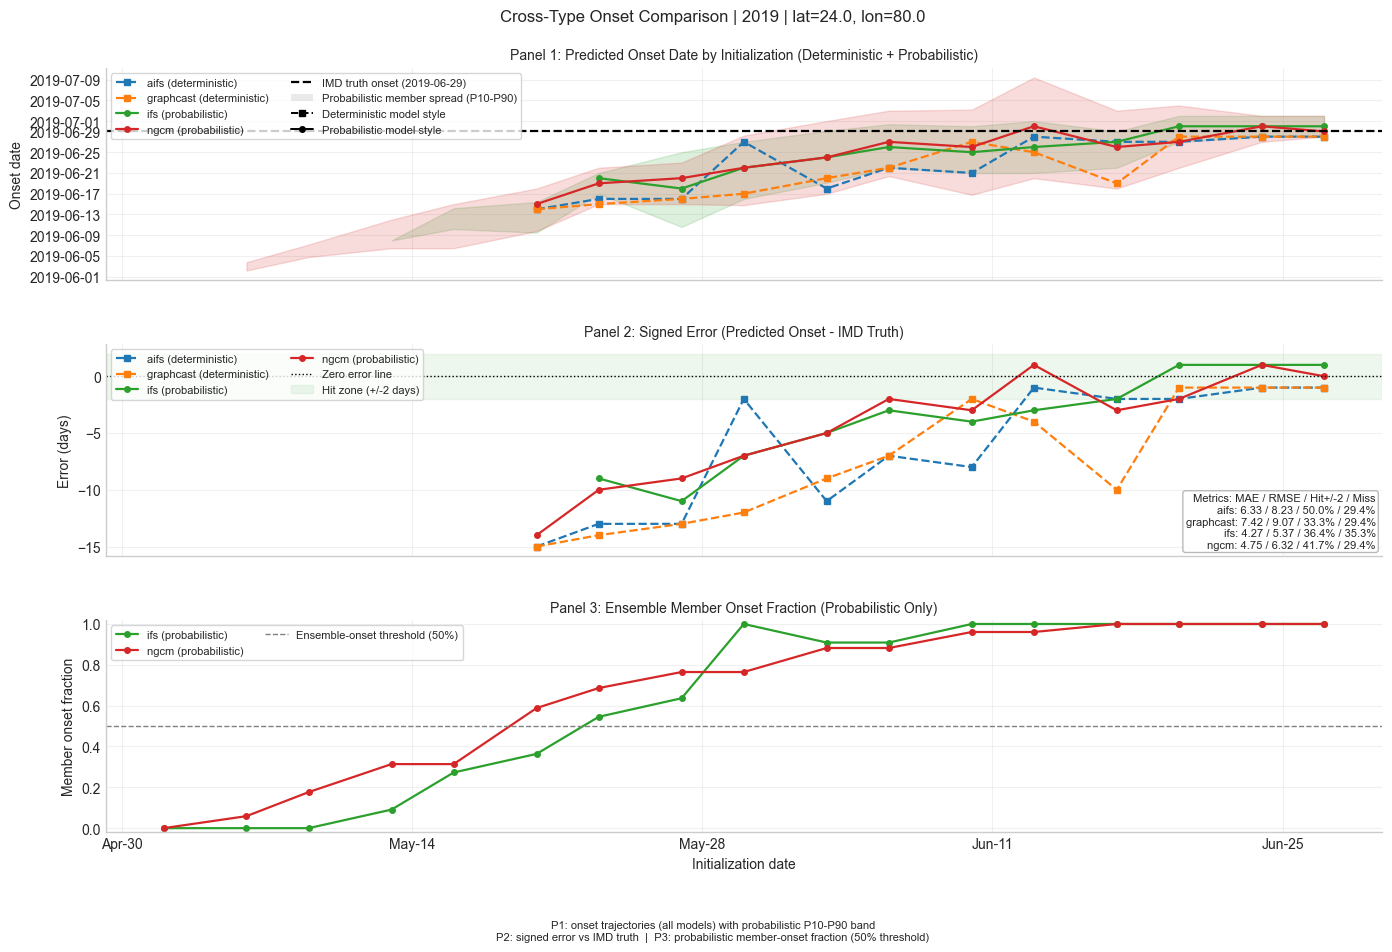

In [14]:
# Build cross-type comparison dataset for one point/year
cross_df, member_df = build_cross_type_onset_timeseries(
    year=example_year,
    point_lat=example_lat,
    point_lon=example_lon,
    model_configs=cross_type_model_configs,
    imd_4deg_dir=imd_4deg_dir,
    thres_4deg_file=thres_4deg_file,
    mok=True,
    max_forecast_day=30,
    onset_window=5,
    min_member_fraction=0.5,
)

metrics_df = summarize_error_metrics(cross_df)

cross_plot_path = out_dir / f'benchmark_cross_type_onset_timeseries_{example_year}.png'
fig_cmp, axes_cmp = plot_cross_type_onset_comparison(
    df_summary=cross_df,
    metrics_df=metrics_df,
    year=example_year,
    save_path=cross_plot_path,
)

print('Nearest grid point:', cross_df.attrs['nearest_lat'], cross_df.attrs['nearest_lon'])
print('Truth onset:', cross_df.attrs['truth_onset'])
print('Threshold (mm/5day):', cross_df.attrs['threshold_mm_5day'])
print('Saved cross-type plot:', cross_plot_path)

metrics_out_csv = out_dir / f'benchmark_cross_type_metrics_{example_year}.csv'
metrics_df.to_csv(metrics_out_csv, index=False)
print('Saved metrics table:', metrics_out_csv)

display(metrics_df)
display(cross_df[['model_name', 'model_type', 'init_time', 'pred_onset_date', 'truth_onset_date', 'error_days']].head(20))

# Optional: ensemble-member level table (for uncertainty diagnostics)
if not member_df.empty:
    member_out_csv = out_dir / f'benchmark_member_level_onset_{example_year}.csv'
    member_df.to_csv(member_out_csv, index=False)
    print('Saved member-level table:', member_out_csv)

plt.show()


## 10) Interpretation
- Panel 1 compares predicted onset-date trajectories across model types at the same point.
- Shaded bands indicate probabilistic member spread (P10 to P90), supporting uncertainty checks.
- Panel 2 shows signed error trajectories; Panel 3 shows ensemble onset fraction dynamics.
- The exported metrics table provides MAE, RMSE, bias, hit rates, miss rate, and spread diagnostics for model-to-model comparison.
